# Lab 01 - Vector Embeddings

**Knowledge base:** `knowledge_base/03_retrieval/04_semantic_search.md`

**Concepts:** Embedding models · Cosine similarity · Euclidean distance · PCA visualization · Input size limits

Vector embeddings are how semantic search works. This lab makes them concrete:
you will embed real text, compare embeddings, visualize them, and discover the input size limit.

---

## Setup

In [1]:
import sys, os
sys.path.insert(0, ".")
from dotenv import load_dotenv
load_dotenv(override=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("✅ Imports OK")

✅ Imports OK


---
## 1 - Distance and similarity formulas

In vector retrieval, you embed queries and documents, then rank documents by how close
they are to the query vector. Two metrics do this:

**Cosine similarity** - measures the *angle* between two vectors. Range: −1 to 1.
A value near 1 means very similar direction (similar meaning).

$$\text{Cosine}(q, d) = \frac{q \cdot d}{\|q\| \cdot \|d\|}$$

**Euclidean distance** - measures the *straight-line* distance. Smaller = more similar.

$$\text{Euclidean}(q, d) = \sqrt{\sum_j (q_j - d_j)^2}$$

In [2]:
def cosine_similarity(v1, array_of_vectors):
    '''
    Cosine similarity between v1 and one or more vectors.
    Returns a list of floats.
    '''
    v1 = np.array(v1, dtype=np.float32).ravel()
    A  = np.array(array_of_vectors, dtype=np.float32)
    if A.ndim == 1:
        A = A.reshape(1, -1)
    v1_norm = np.linalg.norm(v1)
    A_norms = np.linalg.norm(A, axis=1)
    denom = v1_norm * A_norms
    sims = (A @ v1) / np.where(denom == 0, 1.0, denom)
    return sims.tolist()


def euclidean_distance(v1, array_of_vectors):
    '''
    Euclidean distance between v1 and one or more vectors.
    Returns a list of floats.
    '''
    v1 = np.array(v1, dtype=np.float32).ravel()
    A  = np.array(array_of_vectors, dtype=np.float32)
    if A.ndim == 1:
        A = A.reshape(1, -1)
    return [float(np.linalg.norm(v1 - row)) for row in A]


# Quick sanity check on 2D vectors
v1 = [1, 2]
v2 = [1, 1]
array_v = [[3, 2], [5, 6]]

print("Cosine similarity v1 vs v2:", cosine_similarity(v1, v2))
print("Cosine similarity v1 vs array_v:", cosine_similarity(v1, array_v))
print("Euclidean distance v1 vs v2:", euclidean_distance(v1, v2))
print("Euclidean distance v1 vs array_v:", euclidean_distance(v1, array_v))

Cosine similarity v1 vs v2: [0.9486832618713379]
Cosine similarity v1 vs array_v: [0.8682431578636169, 0.9734171032905579]
Euclidean distance v1 vs v2: [1.0]
Euclidean distance v1 vs array_v: [2.0, 5.656854152679443]


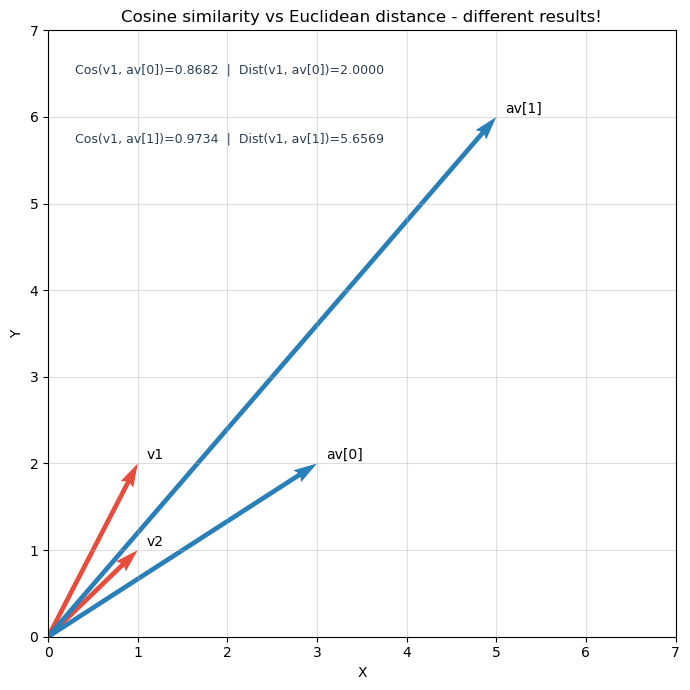


Key insight: cosine similarity measures DIRECTION (angle between vectors).
Euclidean distance measures DISTANCE (straight-line gap between endpoints).
For semantic search, direction is more meaningful than raw distance.


In [3]:
# Visualize the 2D vectors to see WHY the metrics disagree
fig, ax = plt.subplots(figsize=(7, 7))

vectors = {"v1": ([1,2], "#e74c3c"), "v2": ([1,1], "#e74c3c"),
           "av[0]": ([3,2], "#2980b9"), "av[1]": ([5,6], "#2980b9")}

for label, (vec, color) in vectors.items():
    ax.quiver(0, 0, vec[0], vec[1], angles="xy", scale_units="xy", scale=1, color=color)
    ax.text(vec[0]+0.1, vec[1]+0.05, label, fontsize=10)

# Annotations
for i, av in enumerate([[3,2],[5,6]]):
    cs = cosine_similarity(v1, [av])[0]
    ed = euclidean_distance(v1, [av])[0]
    ax.text(0.3, 6.5 - i*0.8,
            f"Cos(v1, av[{i}])={cs:.4f}  |  Dist(v1, av[{i}])={ed:.4f}",
            fontsize=9, color="#2c3e50")

ax.set_xlim(0, 7); ax.set_ylim(0, 7)
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_title("Cosine similarity vs Euclidean distance - different results!", fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print()
print("Key insight: cosine similarity measures DIRECTION (angle between vectors).")
print("Euclidean distance measures DISTANCE (straight-line gap between endpoints).")
print("For semantic search, direction is more meaningful than raw distance.")

---
## 2 - The embedding model

We use `BAAI/bge-base-en-v1.5`, a transformer-based sentence embedding model.
It maps any text string to a 768-dimensional vector.

**Important:** This model downloads on first run (~438 MB). It is cached afterward.

In [4]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "BAAI/bge-base-en-v1.5"
print(f"Loading {MODEL_NAME} ...")
model = SentenceTransformer(MODEL_NAME)
print("✅ Model loaded")

# Embed a single sentence
sample = model.encode("RAG is awesome")
print(f"\nEmbedding shape: {sample.shape}  ← one 768-dimensional vector")
print(f"First 10 values: {sample[:10].round(4)}")

Loading BAAI/bge-base-en-v1.5 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model loaded

Embedding shape: (768,)  ← one 768-dimensional vector
First 10 values: [ 0.0089 -0.0478 -0.0016  0.0131 -0.0021 -0.0616  0.0138  0.001  -0.049
 -0.0476]


### 2.1 Embeddings in practice

Let's see whether semantically related words end up near each other in vector space.

In [5]:
words = ["apple", "car", "fruit", "automobile", "love", "sentiment"]
vecs  = model.encode(words)   # shape: (6, 768)

print(f"Embedded {len(words)} words, each as a {vecs.shape[1]}-dimensional vector\n")

# Compare 'apple' to all words
query_word = "apple"
query_vec  = vecs[words.index(query_word)]

print(f"Cosine similarity to '{query_word}':")
for i, w in enumerate(words):
    sim = cosine_similarity(query_vec, vecs[i])[0]
    bar = "█" * int(sim * 30)
    print(f"  {w:12s}: {sim:.4f}  {bar}")

Embedded 6 words, each as a 768-dimensional vector

Cosine similarity to 'apple':
  apple       : 1.0000  ██████████████████████████████
  car         : 0.5749  █████████████████
  fruit       : 0.7461  ██████████████████████
  automobile  : 0.6485  ███████████████████
  love        : 0.5540  ████████████████
  sentiment   : 0.5020  ███████████████


In [6]:
# Notice: 'fruit' and 'automobile' score higher than 'love'
# because 'apple' is semantically closer to fruit/tech than to emotion

# Now compare 'car' to all words
query_word = "car"
query_vec  = vecs[words.index(query_word)]

print(f"Cosine similarity to '{query_word}':")
for i, w in enumerate(words):
    sim = cosine_similarity(query_vec, vecs[i])[0]
    bar = "█" * int(sim * 30)
    print(f"  {w:12s}: {sim:.4f}  {bar}")

print()
print("'car' and 'automobile' should score much higher than 'apple' or 'love'.")
print("The embedding model learned synonyms from its training data.")

Cosine similarity to 'car':
  apple       : 0.5749  █████████████████
  car         : 1.0000  ██████████████████████████████
  fruit       : 0.5428  ████████████████
  automobile  : 0.8715  ██████████████████████████
  love        : 0.5169  ███████████████
  sentiment   : 0.5184  ███████████████

'car' and 'automobile' should score much higher than 'apple' or 'love'.
The embedding model learned synonyms from its training data.


### 2.2 Retrieve relevant documents by semantic similarity

In [7]:
def retrieve_by_similarity(query: str, documents: list, top_k: int = 3,
                            metric: str = "cosine") -> list:
    '''
    Retrieve top-k documents most similar to the query using embeddings.

    Args:
        query:     The search query.
        documents: List of document strings.
        top_k:     Number of results to return.
        metric:    'cosine' (default) or 'euclidean'.

    Returns:
        List of (score, document) tuples, sorted by relevance.
    '''
    query_emb = model.encode(query)
    doc_embs  = model.encode(documents)

    if metric == "cosine":
        scores = cosine_similarity(query_emb, doc_embs)
        pairs  = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)
    else:
        scores = euclidean_distance(query_emb, doc_embs)
        pairs  = sorted(zip(documents, scores), key=lambda x: x[1])

    return [(score, doc) for doc, score in pairs[:top_k]]


travel_docs = [
    "Mount Fuji is a breathtaking place to explore during autumn.",
    "Santorini offers stunning views to admire during spring.",
    "Banff National Park is a picturesque destination in summer.",
    "The Great Wall of China is spectacular to experience in winter.",
    "The fjords of Norway are magical to cruise through in spring.",
    "Kyoto's cherry blossoms create a beautiful scene in spring.",
    "Marrakech offers vibrant markets to enjoy in the fall.",
    "The Maldives are a paradise to savor during summer.",
]

query = "Suggest great places to visit in Asia."
print(f"Query: {query}\n")
print("Cosine similarity results:")
for score, doc in retrieve_by_similarity(query, travel_docs, top_k=3, metric="cosine"):
    print(f"  [{score:.4f}] {doc}")

Query: Suggest great places to visit in Asia.

Cosine similarity results:
  [0.6189] The Great Wall of China is spectacular to experience in winter.
  [0.6063] Mount Fuji is a breathtaking place to explore during autumn.
  [0.6007] The Maldives are a paradise to savor during summer.


---
## 3 - Visualizing embeddings with PCA

768 dimensions cannot be visualized. PCA reduces them to 2 dimensions
so we can see which words cluster together in semantic space.

PCA explains 24.7% + 14.9% = 39.7% of variance


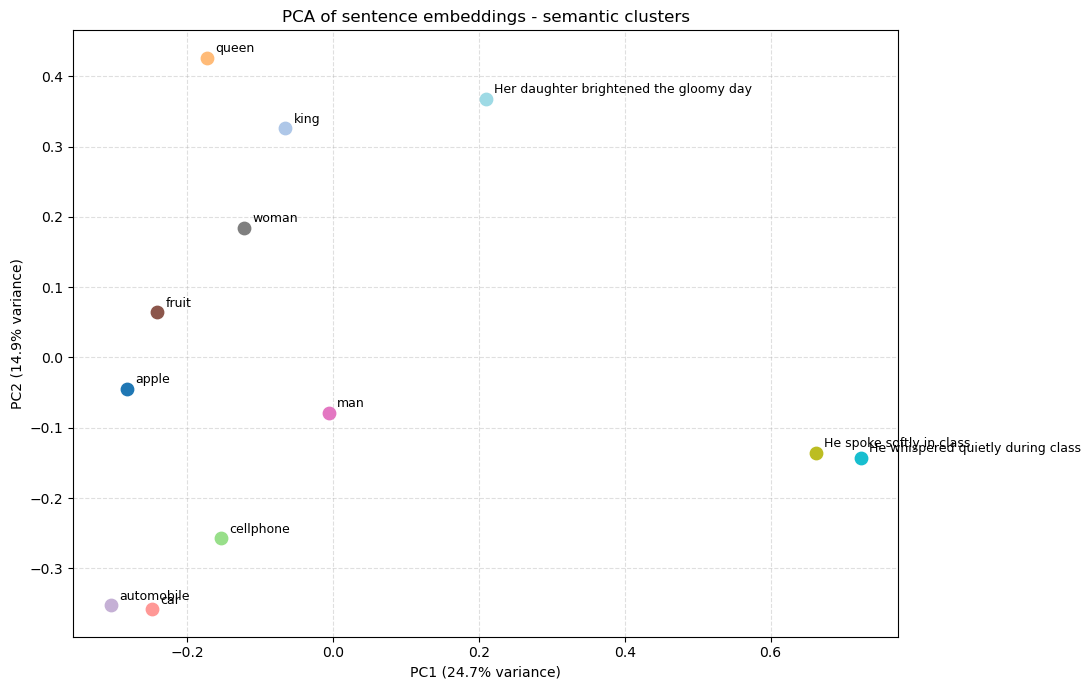


Semantically related words should cluster together.
'car' and 'automobile' should be close. 'apple' and 'fruit' should be close.
'He spoke softly' and 'He whispered quietly' should be very close.


In [8]:
sentences = [
    "apple", "king", "queen", "cellphone", "car", "automobile",
    "fruit", "man", "woman",
    "He spoke softly in class",
    "He whispered quietly during class",
    "Her daughter brightened the gloomy day",
]

embeddings  = model.encode(sentences)
pca         = PCA(n_components=2)
coords_2d   = pca.fit_transform(embeddings)

explained = pca.explained_variance_ratio_
print(f"PCA explains {explained[0]*100:.1f}% + {explained[1]*100:.1f}% = {sum(explained)*100:.1f}% of variance")

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(sentences)))

for (x, y), label, color in zip(coords_2d, sentences, colors):
    ax.scatter(x, y, color=color, s=80, zorder=2)
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(6, 4), fontsize=9, color="black")

ax.set_title("PCA of sentence embeddings - semantic clusters", fontsize=12)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print()
print("Semantically related words should cluster together.")
print("'car' and 'automobile' should be close. 'apple' and 'fruit' should be close.")
print("'He spoke softly' and 'He whispered quietly' should be very close.")

---
## 4 - Input size limit and truncation

Embedding models have a token limit - for `bge-base-en-v1.5` it is **512 tokens**.
Text beyond this limit is silently truncated. No error is raised - the model just ignores the rest.

In [9]:
# Create a very long text by repeating a sentence many times
long_text  = "The embedding model converts text to a fixed-size vector. " * 500
short_text = long_text[:3000]   # keep only first 3000 characters

print(f"Long text length:  {len(long_text):,} characters")
print(f"Short text length: {len(short_text):,} characters")
print()

emb_long  = model.encode(long_text)
emb_short = model.encode(short_text)

identical = np.array_equal(emb_long, emb_short)
print(f"Are the two embeddings identical? {identical}")
print()
if identical:
    print("✅ Confirmed: both produce the SAME vector.")
    print("   Everything beyond the 512-token limit is silently ignored.")
    print()
    print("   This is why chunking is essential:")
    print("   long documents must be split into 512-token chunks BEFORE embedding.")

Long text length:  29,000 characters
Short text length: 3,000 characters

Are the two embeddings identical? True

✅ Confirmed: both produce the SAME vector.
   Everything beyond the 512-token limit is silently ignored.

   This is why chunking is essential:
   long documents must be split into 512-token chunks BEFORE embedding.


---
## 5 - Exercise

1. Embed the five sentences below.
2. Find the two sentences most similar to the query using cosine similarity.
3. Print the top-2 with their scores.

In [ ]:
query = "I want to learn about machine learning."

candidate_sentences = [
    "Deep learning is a subfield of machine learning using neural networks.",
    "The weather in Cairo is very hot during summer.",
    "Gradient descent is an optimization algorithm used to train ML models.",
    "The pyramids of Giza are one of the seven wonders of the ancient world.",
    "Supervised learning requires labeled training data.",
]

# YOUR CODE HERE
# Hint: use retrieve_by_similarity() with metric='cosine'

top_2 = # YOUR CODE HERE

print("Top-2 most relevant to the query:")
for score, doc in top_2:
    print(f"  [{score:.4f}] {doc}")

assert len(top_2) == 2
assert all(isinstance(s, float) for s, _ in top_2)
print("\n✅ Exercise passed")

---
**Lab 01 complete.**

You understand what embeddings are, how to compute similarity between them,
and the critical 512-token input limit that makes chunking necessary.

**Next:** `lab02_keyword_search.ipynb` - TF-IDF and BM25 keyword retrieval.